In [1]:
# Confirm that JSBSim is installed. If not and running on Google Colab
# then install JSBSim into the Google Colab instance.

import os

try:
  import jsbsim
  print('JSBSim is installed')
  print(f'Current working directory: {os.getcwd()}')
except ImportError:
  import sys
  if 'google.colab' in sys.modules:
      print('Installing JSBSim...')
      !pip install jsbsim
  else:
    sys.path.append('../../build/Debug/tests')
    import jsbsim

# Prepare data

Load the exact solutions from the CSV file `top.csv`. The exact solutions has been computed using van Zon and Schofield's algorithm in *Numerical implementation of the exact dynamics of free rigid bodies*.

In [2]:
import enum
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

class ODE_methods(enum.IntEnum):
    NONE = 0
    EULER = 1
    TRAPEZOID = 2
    ADAMS_BASHFORTH2 = 3
    ADAMS_BASHFORTH3 = 4
    ADAMS_BASHFORTH4 = 5
    BUSS1 = 6
    BUSS2 = 7
    LOCAL_LINEARIZATION = 8
    ADAMS_BASHFORTH5 = 9

# For plots legend.
method_names = ["None", "Euler", "Trapezoid", "Adams-BashForth 2", "Adams-BashForth 3",
                "Adams-BashForth 4", "Buss 1", "Buss 2", "Local linearization",
                "Adams-BashForth 5"]

# Load the exact resolution of the free rigid body rotation
exact = pd.read_csv('data/top.csv', header=None, sep='\\s+')

nvalues = len(exact.iloc[:,0])
freq = int(nvalues / exact.iloc[-1,0])
t_final = nvalues / freq

# Compute the Euler angles of the exact solution
# - Columns 4 to 12 contain the Ti2b matrix values
# - Ti2b is the transform matrix from inertial frame to the body frame
Ti2b_data = exact.iloc[:, 4:13].values # Extract the data of matrices (one per time step)
Ti2b = Ti2b_data.reshape(-1, 3, 3)
rotations = R.from_matrix(Ti2b)
euler_angles = rotations.as_euler('zyx', degrees=False)
# In JSBSim, Euler angles measure the body attitude with respect to the inertial frame
# so we need to change the sign of the Euler angles from the exact computation.
exact[13] = -euler_angles[:, 2] # Roll
exact[14] = -euler_angles[:, 1] # Pitch
exact[15] = -euler_angles[:, 0] # Yaw
# In JSBSim, yaw is measuring the heading from 0 (North) to 2pi
exact[15] = exact[15] % (2.0*np.pi)

# Avoid flooding messages
jsbsim.FGJSBBase().debug_lvl = 0  # Disable debug introspection.
jsbsim.get_logger().set_min_level(jsbsim.LogLevel.WARN)  # Ignore info messages

In [3]:
methods = ((ODE_methods.ADAMS_BASHFORTH2, 180),
           (ODE_methods.ADAMS_BASHFORTH3, 120),
           (ODE_methods.ADAMS_BASHFORTH3, 180),
           (ODE_methods.ADAMS_BASHFORTH4, 120),
           (ODE_methods.ADAMS_BASHFORTH5, 60))

nsteps = max([int(m[1]*t_final) for m in methods])

times = np.empty((len(methods), nsteps))
p = np.empty((len(methods), nsteps))
q = np.empty((len(methods), nsteps))
r = np.empty((len(methods), nsteps))
roll = np.empty((len(methods), nsteps))
pitch = np.empty((len(methods), nsteps))
yaw = np.empty((len(methods), nsteps))

for j, method in enumerate(methods):
    fdm = jsbsim.FGFDMExec(".")
    fdm.set_aircraft_path('data')
    fdm.load_model('top', False)
    fdm.set_dt(1.0/float(method[1]))
    fdm['ic/p-rad_sec'] = 1.0
    fdm['ic/q-rad_sec'] = 15.0
    fdm['ic/r-rad_sec'] = 1.0
    fdm['ic/phi-rad'] = 0.0
    fdm['ic/theta-rad'] = 0.0
    fdm['ic/psi-true-rad'] = 0.0
    fdm['simulation/integrator/rate/rotational'] = method[0]
    fdm['simulation/integrator/position/rotational'] = 7
    fdm.run_ic()

    for i in range(nsteps):
        times[j, i] = fdm.get_sim_time()
        p[j, i] = fdm['velocities/p-rad_sec']
        q[j, i] = fdm['velocities/q-rad_sec']
        r[j, i] = fdm['velocities/r-rad_sec']
        roll[j, i] = fdm['attitude/roll-rad']
        pitch[j, i] = fdm['attitude/pitch-rad']
        yaw[j, i] = fdm['attitude/psi-rad']

        fdm.run()


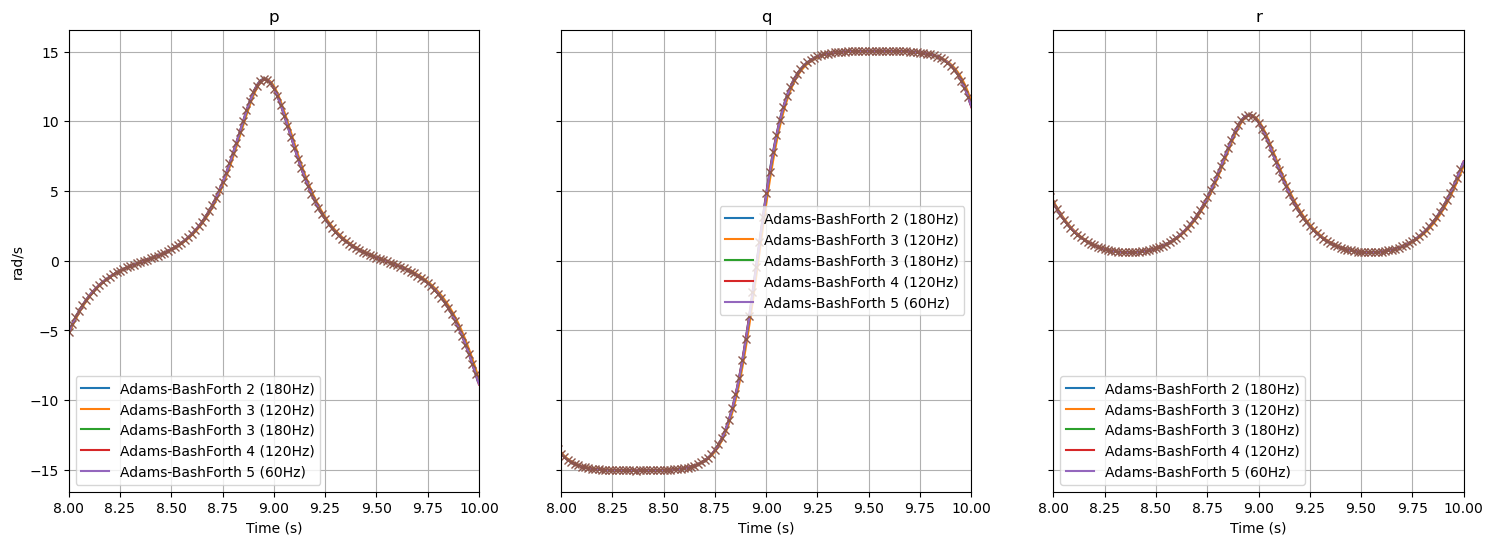

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i in range(len(methods)):
    ax1.plot(times[i, :], p[i, :], label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax1.plot(exact.iloc[:, 0], exact.iloc[:,1], 'x')
ax1.set_title("p")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("rad/s")
ax1.set_xlim(8, 10)
ax1.legend()
ax1.grid()

for i in range(len(methods)):
    ax2.plot(times[i, :], q[i, :], label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax2.plot(exact.iloc[:, 0], exact.iloc[:,2], 'x')
ax2.set_title("q")
ax2.set_xlabel("Time (s)")
ax2.set_xlim(8, 10)
ax2.legend()
ax2.grid()

for i in range(len(methods)):
    ax3.plot(times[i, :], r[i, :], label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax3.plot(exact.iloc[:, 0], exact.iloc[:,3], 'x')
ax3.set_title("r")
ax3.set_xlabel("Time (s)")
ax3.set_xlim(8, 10)
ax3.legend()
ax3.grid()


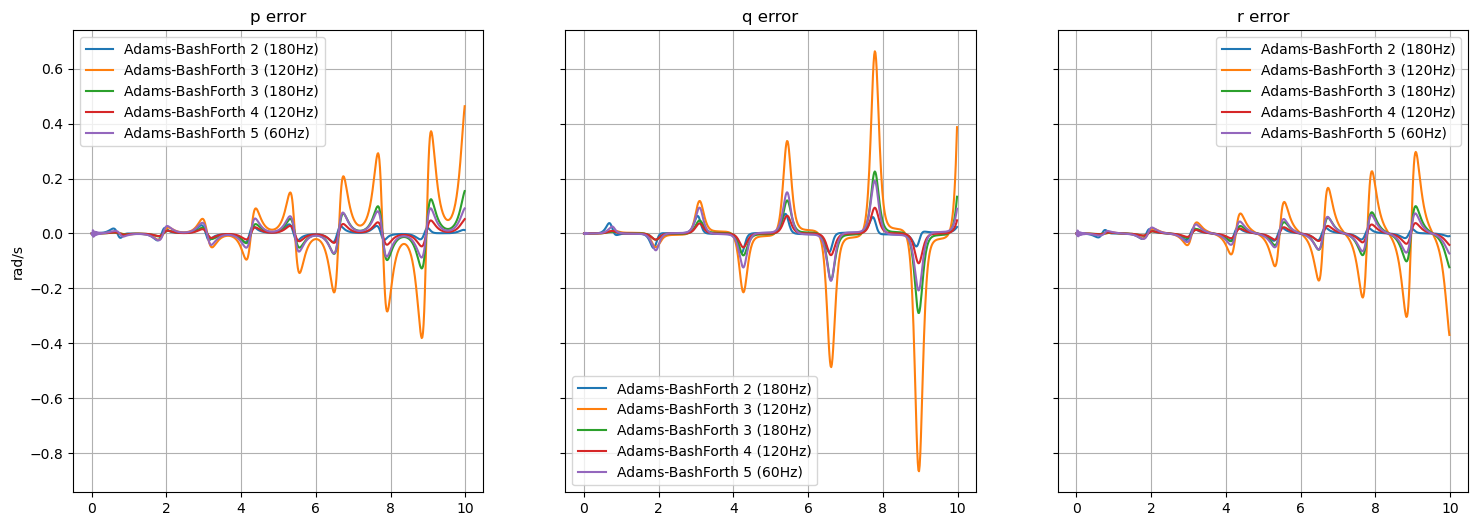

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

v = exact.iloc[:,1].values
dp = np.empty(nvalues)

for i in range(len(methods)):
    step = int(methods[i][1]/freq)
    dp = p[i, :step*nvalues:step] - v
    ax1.plot(exact.iloc[:,0], dp, label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax1.set_title("p error")
ax1.set_ylabel("rad/s")
ax1.legend()
ax1.grid()

v = exact.iloc[:,2].values
dq = np.empty(dp.shape)

for i in range(len(methods)):
    step = int(methods[i][1]/freq)
    dq = q[i, :step*nvalues:step] - v
    ax2.plot(exact.iloc[:,0], dq, label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax2.set_title("q error")
ax2.legend()
ax2.grid()

v = exact.iloc[:,3].values
dr = np.empty(dp.shape)

for i in range(len(methods)):
    step = int(methods[i][1]/freq)
    dr = r[i, :step*nvalues:step] - v
    ax3.plot(exact.iloc[:,0], dr, label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax3.set_title("r error")
ax3.legend()
ax3.grid()


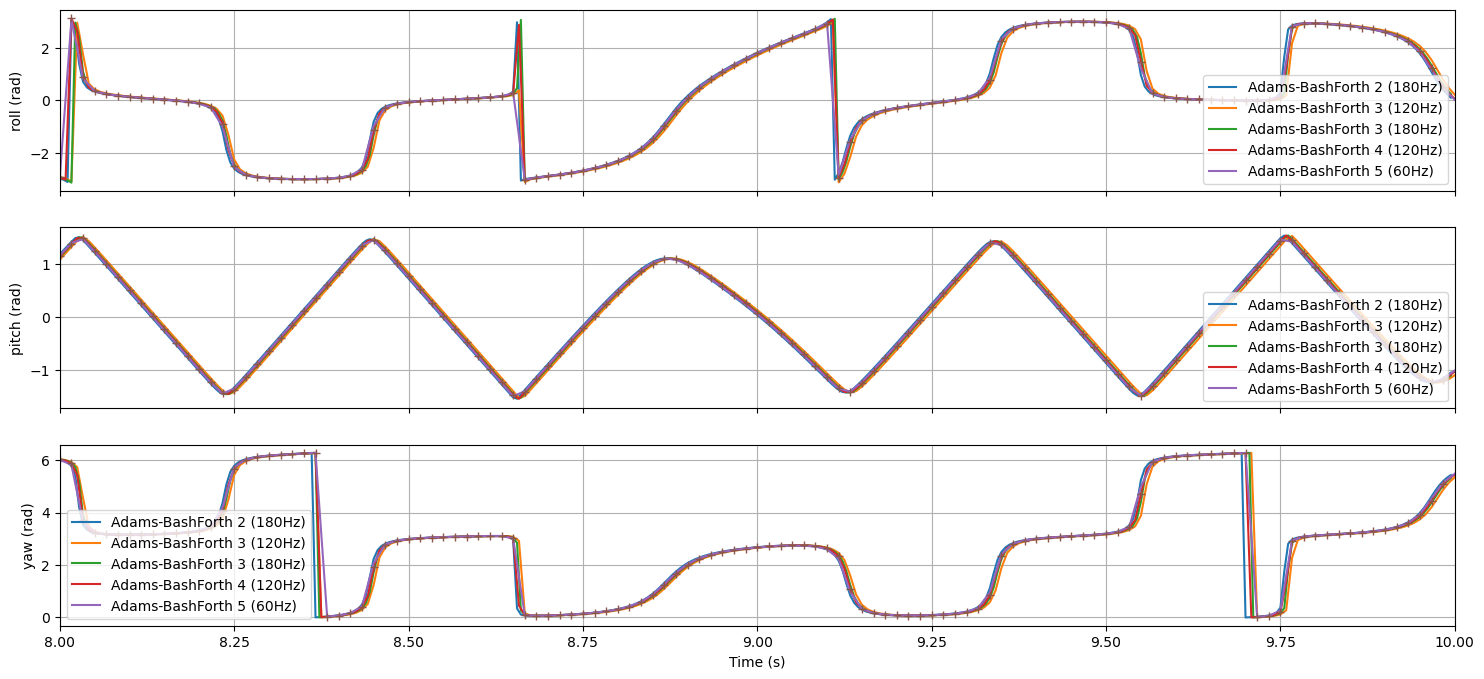

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

for i in range(len(methods)):
    ax1.plot(times[i, :], roll[i, :], label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax1.plot(exact.iloc[:, 0], exact.iloc[:, 13], '+')
ax1.grid()
ax1.set_ylabel("roll (rad)")
ax1.legend()

for i in range(len(methods)):
    ax2.plot(times[i, :], pitch[i, :], label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax2.plot(exact.iloc[:, 0], exact.iloc[:,14], '+')
ax2.grid()
ax2.set_ylabel("pitch (rad)")
ax2.legend()

for i in range(len(methods)):
    ax3.plot(times[i, :], yaw[i, :], label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax3.plot(exact.iloc[:, 0], exact.iloc[:,15], '+')
ax3.legend()
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("yaw (rad)")
ax3.set_xlim(8, 10)
ax3.grid()


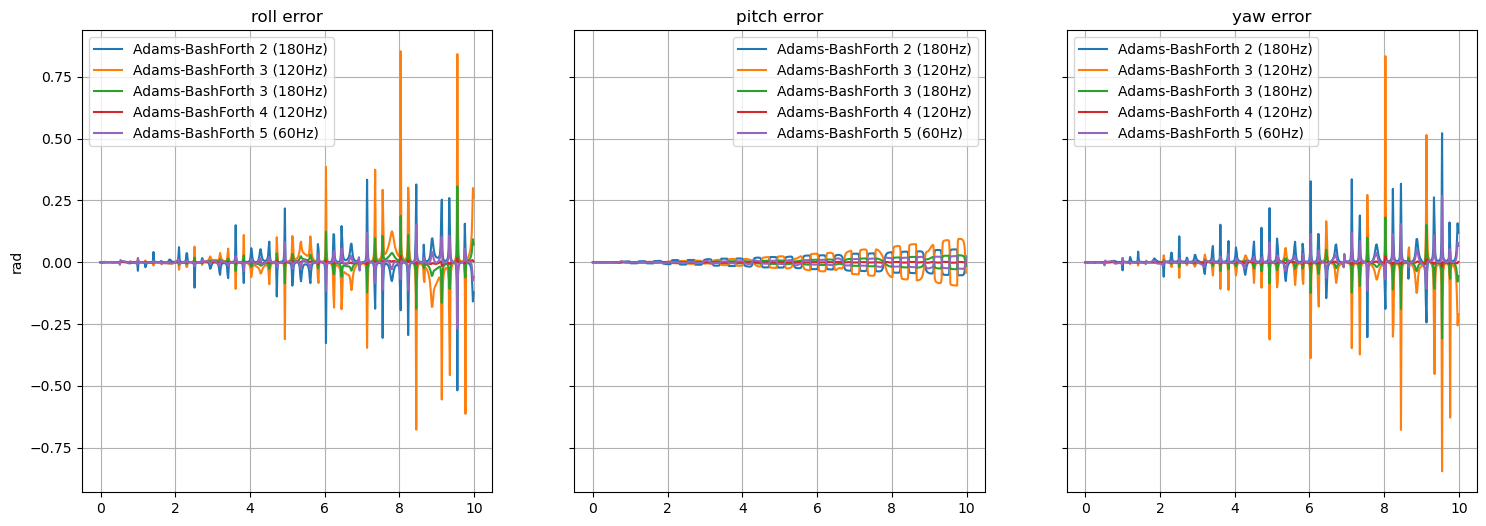

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

v = exact.iloc[:,13].values
droll = np.empty(dp.shape)

def mod_2pi(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi

for i in range(len(methods)):
    step = int(methods[i][1]/freq)
    droll = mod_2pi(roll[i, :step*nvalues:step] - v)
    ax1.plot(exact.iloc[:,0], droll, label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax1.set_title("roll error")
ax1.set_ylabel("rad")
ax1.legend()
ax1.grid()

v = exact.iloc[:,14].values
dpitch = np.empty(dp.shape)

for i in range(len(methods)):
    step = int(methods[i][1]/freq)
    dpitch = mod_2pi(pitch[i, :step*nvalues:step] - v)
    ax2.plot(exact.iloc[:,0], dpitch, label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax2.set_title("pitch error")
ax2.legend()
ax2.grid()

v = exact.iloc[:,15].values
dyaw = np.empty(dp.shape)

for i in range(len(methods)):
    step = int(methods[i][1]/freq)
    dyaw = mod_2pi(yaw[i, :step*nvalues:step] - v)
    ax3.plot(exact.iloc[:,0], dyaw, label=method_names[methods[i][0]]+f" ({methods[i][1]:.0f}Hz)")
ax3.set_title("yaw error")
ax3.legend()
ax3.grid()
